# When two members tie at fiftieth place, how many does a list ship, and which rule did the head of Retail-Plus ask for?

**Week 2, Wednesday. Chapter 3 of 6.** Chapter 2 built one list per segment; this chapter
decides what happens when the fiftieth place is shared.

> "Ties matter. If two members spent the same, I want them ranked the same, and I want to
> know how many made the top fifty, not forty-nine because of a tie."
> The head of Retail-Plus, Kalpa Retail

**Who needs the answer.** The head of Retail-Plus owns Kalpa's paid membership tier and will
defend the list to its members and to Marketing. A member left off by a coin toss, with the
same spend as the member kept, has a fair complaint; a list labelled fifty that carries
fifty-two has spent two calls nobody planned; a list that drops both members of a tie at the
line is the forty-nine the head has already refused.

**The questions on the way.**
1. Which rules could cut a list at fifty, and what does each do at a tie?
2. How many rows does each rule ship when two members tie at the line?
3. What do ROW_NUMBER, RANK and DENSE_RANK give on one tie?
4. How many Retail-Core members does each rule ship?
5. How many members does Retail-Plus's list ship under the head's rule, counted in your own run?
6. Does a count with no window agree with RANK?

**The metric at stake.** The count of members on each segment's list, beside Q2 revenue per
member, the booked amount of every Q2 order whatever its status (Q2 is July to September
2026). Two members tie when their Q2 revenue is the same to the rupee. The line is the last
place a list keeps, fiftieth on a top fifty. The retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, section 4, says what the head of Retail-Plus owns: the tier's members, their
fees and their renewals.

**What chapter 2 found.** PARTITION BY segment gives each segment its own list: 155 members,
Business 35 and Student 20 (every buyer in both), Retail-Core 50 and Retail-Plus 50. Those
lists were cut by `row_number()`, with the customer id deciding any two members who booked
the same, which is the rule this chapter questions.

**A real company with the same question.** American Airlines gives its limited upgrade seats
to AAdvantage members in a stated order, status tier, then type of upgrade, then Loyalty
Points earned in the last 12 months, and writes its tiebreaker down in advance: "If the
upgrade type and 12-month Loyalty Point value are the same, we'll look at the booking code
then date / time of the request to determine priority" (aa.com, upgrades for status members,
checked 1 October 2026). That is a hard cap with a stated tiebreaker. Sport shows RANK's
rule: in the Tokyo 2020 men's high jump final on 1 August 2021, Barshim of Qatar and Tamberi
of Italy both cleared 2.37 m and shared the gold, and Nedasekau of Belarus, the next
athlete, was placed third and took the bronze, with no silver awarded (World Athletics
results, checked 1 October 2026).

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D03_03_tie_rule_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = blocks("03_tie_rule")
print(len(Q), "named queries read from", "C2_W02_D03_03_tie_rule_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

8 named queries read from C2_W02_D03_03_tie_rule_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


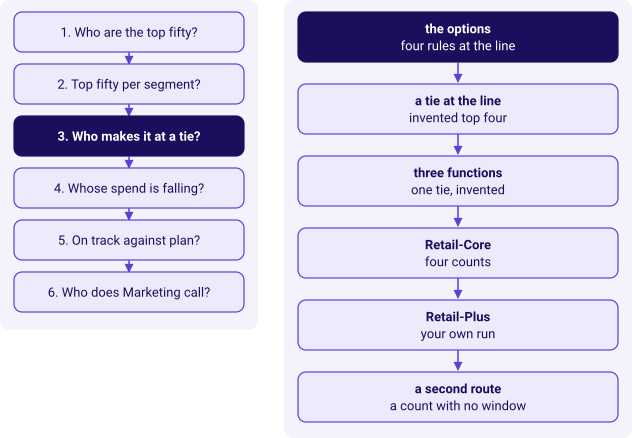

In [2]:
kit.side_by_side(
    kit.ladder(['Who are the top fifty?', 'Top fifty per segment?', 'Who makes it at a tie?', 'Whose spend is falling?', 'On track against plan?', 'Who does Marketing call?'], lit=2, show=False),
    kit.vflow(['the options\nfour rules at the line', 'a tie at the line\ninvented top four', 'three functions\none tie, invented', 'Retail-Core\nfour counts', 'Retail-Plus\nyour own run', 'a second route\na count with no window'], lit=0, show=False),
)

## The options: which rules could cut a list at fifty, and what does each do at a tie?

The line is the last place a list keeps, fiftieth on a top fifty, and two members tie at the
line when the member at fiftieth and the member just below spent the same.

| Rule | At a tie on the line | Meets "ranked the same, and say how many"? | What it costs |
|---|---|---|---|
| A. ROW_NUMBER with a stated tiebreaker | one tied member in, one out, decided by the tiebreaker | No: two members who spent the same get different places | a member with the same spend is left off, by a rule the business has to defend |
| B. RANK | both in, and the next place is skipped: 1, 1, 3 | Yes, and the count says so | the list can run past fifty, and the report has to say why |
| C. DENSE_RANK | both in, and no place is skipped: 1, 1, 2 | Ties share a place, but its numbers count spend figures, not members | the list can run past fifty even with no tie at the line |
| D. Whole ties only | a tie that straddles the line is left out whole | Ties share a place, but the list runs short | the forty-nine the head of Retail-Plus refused |

Whole ties only has no function of its own. `count(*) OVER (PARTITION BY q2_revenue)` gives
each member the number of members who share their figure, and `rank + tied_with - 1` is the
last place the tie reaches; the rule keeps a tie only when that place is inside the line.

**The best-fit call.** RANK, with the count and its reason in the report. It is the only rule
that both ranks equal spend equally and never drops a member at the line, and the head of
Retail-Plus asked for the count. What would change the call is a hard cap that cannot
stretch, such as fifty seats at a members' dinner or fifty gift boxes already packed. Then
ROW_NUMBER with a tiebreaker the business states in advance, such as more Q2 orders first,
is honest, as long as the report names who was left off and why. Section 1 sizes each rule
in the rows it ships when a tie sits on the line.

## 1. How many rows does each rule ship when two members tie at the line?

An invented top four, labelled invented: A to F spent Rs 9,100, 8,800, 8,200, 7,400, 7,400 and
6,900, so D and E tie at fourth, on the line of a top four.

**Predict before you run.** How many rows does RANK ship for the top four?

- a) 4.
- b) 5.
- c) 3.
- d) 6.

-- Invented again: a top four, where the fourth and fifth members spent the same.
-- tied_with counts the members who share a row's spend, so rank + tied_with - 1 is the last place
-- the tie reaches, and "whole ties only" keeps a tie only when that last place is inside the line.
WITH invented (member, spend) AS (
    VALUES ('A', 9100), ('B', 8800), ('C', 8200), ('D', 7400), ('E', 7400), ('F', 6900)
),
r AS (
    SELECT member, spend,
           row_number() OVER (ORDER BY spend DESC, member) AS rn,
           rank()       OVER (ORDER BY spend DESC)         AS rk,
           dense_rank() OVER (ORDER BY spend DESC)         AS dr,
           count(*)     OVER (PARTITION BY spend)          AS tied_with
    FROM   invented
)
SELECT count(*) FILTER (WHERE rn <= 4)                 AS row_number_ships,
       count(*) FILTER (WHERE rk <= 4)                 AS rank_ships,
       count(*) FILTER (WHERE dr <= 4)                 AS dense_rank_ships,
       count(*) FILTER (WHERE rk + tied_with -

row_number_ships,rank_ships,dense_rank_ships,whole_ties_only_ships
4,5,5,3


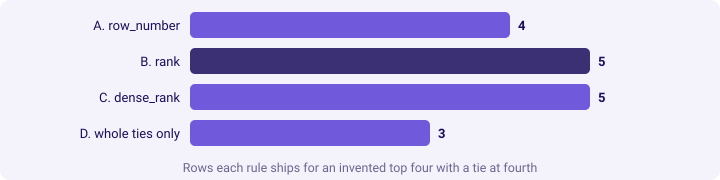

In [3]:
line = run("c3_invented_line", "Invented numbers: a top four where the fourth and fifth members tie")[0]
kit.bars([("A. row_number", line["row_number_ships"]), ("B. rank", line["rank_ships"]),
          ("C. dense_rank", line["dense_rank_ships"]), ("D. whole ties only", line["whole_ties_only_ships"])],
         title="Rows each rule ships for an invented top four with a tie at fourth", lit=(1,))

**What happened.** The answer is b: RANK ships 5, because the two members tied at fourth
share fourth place. ROW_NUMBER ships 4 and leaves one of the pair off by its tiebreaker,
DENSE_RANK ships 5 here, and whole ties only ships 3, dropping both tied members. At a tie on
the line the rules ship different counts, so the report states its count; this is the
forty-nine or fifty-one the head of Retail-Plus spoke of, at four in place of fifty.

In [4]:
kit.check("RANK ships five for the invented top four", line["rank_ships"] == 5)
kit.check("ROW_NUMBER always ships exactly the list size", line["row_number_ships"] == 4)
kit.check("whole ties only runs short", line["whole_ties_only_ships"] == 3)

## 2. What do ROW_NUMBER, RANK and DENSE_RANK give on one tie?

Six invented members, labelled invented: A and B spent Rs 7,500 each, C Rs 6,000, D and E
Rs 5,200 each and F Rs 4,100.

**Predict before you run.** What does RANK give the six, in order?

- a) 1, 2, 3, 4, 5, 6.
- b) 1, 1, 3, 4, 4, 6.
- c) 1, 1, 2, 3, 3, 4.
- d) 1, 1, 1, 2, 2, 3.

-- Invented numbers, for the mechanism only: six members, and A and B spent the same.
WITH invented (member, spend) AS (
    VALUES ('A', 7500), ('B', 7500), ('C', 6000), ('D', 5200), ('E', 5200), ('F', 4100)
)
SELECT member, spend,
       row_number() OVER (ORDER BY spend DESC, member) AS row_number,
       rank()       OVER (ORDER BY spend DESC)         AS rank,
       dense_rank() OVER (ORDER BY spend DESC)         AS dense_rank
FROM   invented
ORDER  BY spend DESC, member;


member,spend,row_number,rank,dense_rank
A,"Rs 7,500",1,1,1
B,"Rs 7,500",2,1,1
C,"Rs 6,000",3,3,2
D,"Rs 5,200",4,4,3
E,"Rs 5,200",5,4,3
F,"Rs 4,100",6,6,4


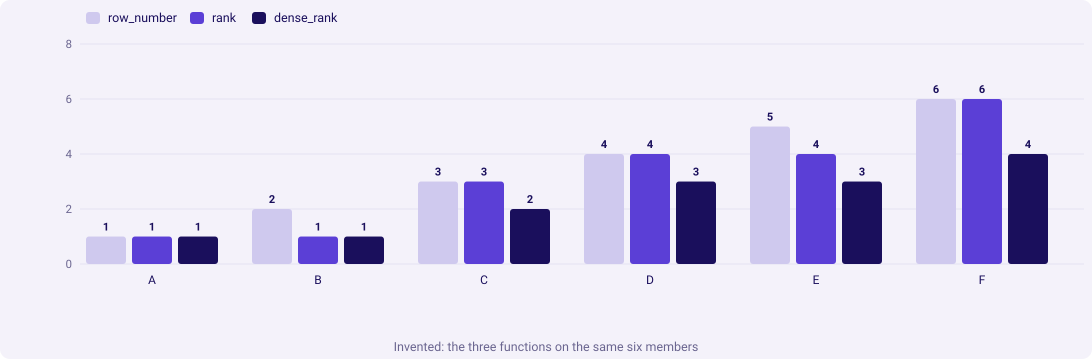

In [5]:
six = run("c3_invented_three", "Invented numbers: three functions on six members with two ties", money=("spend",))
kit.columns([r["member"] for r in six],
            [("row_number", [r["row_number"] for r in six]), ("rank", [r["rank"] for r in six]),
             ("dense_rank", [r["dense_rank"] for r in six])],
            title="Invented: the three functions on the same six members")

**What happened.** The answer is b. ROW_NUMBER gives 1 to 6 and puts A ahead of B only
because the tiebreaker sorts A first. RANK gives A and B the same 1 and skips 2, so C is
third, as a race reports a shared first place. DENSE_RANK gives 1, 1, 2, 3, 3, 4: it numbers
the different spend figures, so it never skips, and by F its number, 4, is two below F's
place among the members, 6.

In [6]:
kit.check("ROW_NUMBER never repeats a number", [r["row_number"] for r in six] == [1, 2, 3, 4, 5, 6])
kit.check("RANK repeats a tie and skips after it", [r["rank"] for r in six] == [1, 1, 3, 4, 4, 6])
kit.check("DENSE_RANK repeats a tie and never skips", [r["dense_rank"] for r in six] == [1, 1, 2, 3, 3, 4])
kit.check("DENSE_RANK falls two behind the member count after two ties",
          six[-1]["rank"] - six[-1]["dense_rank"] == 2)

## 3. How many Retail-Core members does each rule ship?

The same four counts now run on Kalpa. Retail-Core, the everyday shoppers, has 96 Q2
buyers, so its top fifty is a real cut. A hurried analyst reads "ties ranked the same" and
reaches for DENSE_RANK, since its numbers never skip.

**Predict before you run.** How many Retail-Core members does DENSE_RANK put on a top-fifty
list?

- a) 50.
- b) 49.
- c) 51.
- d) 52.

-- The question: how many Retail-Core members does each rule put on a top-fifty list?
WITH q2 AS (
    SELECT c.segment, o.customer_id, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id
),
r AS (
    SELECT segment, customer_id, q2_revenue,
           row_number() OVER (PARTITION BY segment ORDER BY q2_revenue DESC, customer_id) AS rn,
           rank()       OVER (PARTITION BY segment ORDER BY q2_revenue DESC)              AS rk,
           dense_rank() OVER (PARTITION BY segment ORDER BY q2_revenue DESC)              AS dr,
           count(*)     OVER (PARTITION BY segment, q2_revenue)                           AS tied_with
    FROM   q2
)
SELECT segment,
       count(*) FILTER (WHERE rn <= 50)                 AS row_number_ships,
       count(*) FILTER (WHERE rk <= 50)                 AS rank_ships,
       count(*) FILTER (WHERE dr <= 50)                 AS dense_rank_ships,


segment,row_number_ships,rank_ships,dense_rank_ships,whole_ties_only_ships
Retail-Core,50,50,52,50


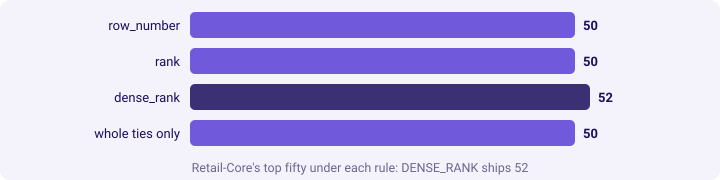

In [7]:
core = run("c3_core_counts", "Retail-Core: the rows each rule ships")[0]
kit.bars([("row_number", core["row_number_ships"]), ("rank", core["rank_ships"]),
          ("dense_rank", core["dense_rank_ships"]), ("whole ties only", core["whole_ties_only_ships"])],
         title="Retail-Core's top fifty under each rule: DENSE_RANK ships 52", lit=(2,))

**The plausible wrong answer.** "DENSE_RANK keeps ties together, so Retail-Core's top fifty is
these 52 members." The answer to the prediction is d.

**Why it is wrong.** DENSE_RANK numbers spend figures, and two pairs of members higher up the
list share a figure, so its numbers run two behind the members. Its fiftieth number lands on
the 52nd member. The 51st and 52nd members tie with nobody at the line, yet Marketing would
call them as part of a top fifty, and the head of Retail-Plus would sign a list that
overstates its own cut.

**The check that exposes it.** Read the members around fiftieth place with all three
functions side by side, and list the ties inside the first fifty.

row_number,rank,dense_rank,customer_id,q2_revenue
46,46,44,C-0007,"Rs 3,100"
47,47,45,C-0127,"Rs 3,030"
48,48,46,C-0054,"Rs 3,000"
49,49,47,C-0072,"Rs 2,990"
50,50,48,C-0005,"Rs 2,980"
51,51,49,C-0092,"Rs 2,950"
52,52,50,C-0094,"Rs 2,910"
53,53,51,C-0048,"Rs 2,870"
54,54,52,C-0074,"Rs 2,810"


row_number,customer_id,q2_revenue,tied_with
31,C-0044,"Rs 4,540",2
32,C-0132,"Rs 4,540",2
37,C-0060,"Rs 4,120",2
38,C-0121,"Rs 4,120",2


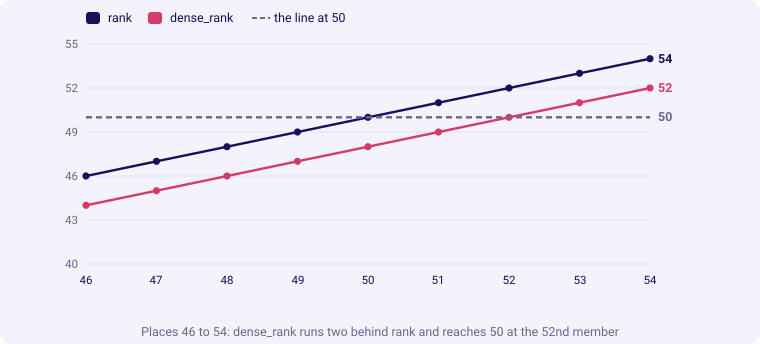

In [8]:
near = run("c3_core_line", "Retail-Core around fiftieth place, three functions side by side", money=("q2_revenue",),
           echo=False)
ties = run("c3_core_ties", "The ties inside Retail-Core's first fifty", money=("q2_revenue",), echo=False)
kit.line([str(r["row_number"]) for r in near],
         [("rank", [r["rank"] for r in near], "lit"), ("dense_rank", [r["dense_rank"] for r in near], "bad"),
          ("the line at 50", [50 for _ in near], "plan")],
         title="Places 46 to 54: dense_rank runs two behind rank and reaches 50 at the 52nd member",
         fmt=lambda v: f"{v:.0f}", lo=40)

**What happened.** Two ties sit inside the list, two members on Rs 4,540 at places 31 and 32,
and two on Rs 4,120 at places 37 and 38. Each tie costs DENSE_RANK one number, so its 50
falls on C-0094, the 52nd member, on Rs 2,910. Nobody ties at Retail-Core's line: the
fiftieth member, C-0005, booked Rs 2,980 and the 51st, C-0092, Rs 2,950.

**The fix, and what it changed.** RANK, the head's rule, ships 50 for Retail-Core, the same
fifty as ROW_NUMBER, because no tie straddles the line, so here the head's rule costs
nothing. The fix takes two members, C-0092 and C-0094, off a list they never belonged on.

In [9]:
kit.check("RANK ships 50 for Retail-Core", core["rank_ships"] == 50)
kit.check("two ties inside the first fifty, two members each", len(ties) == 4 and all(t["tied_with"] == 2 for t in ties))
kit.check("DENSE_RANK reaches 50 at the 52nd member",
          [r["row_number"] for r in near if r["dense_rank"] == 50] == [52])
kit.check("nobody ties at Retail-Core's fiftieth place",
          [r["q2_revenue"] for r in near if r["row_number"] == 50] != [r["q2_revenue"] for r in near if r["row_number"] == 51])

## 4. How many members does Retail-Plus's list ship under the head's rule, counted in your own run?

**Your turn.** The head of Retail-Plus asked about their own tier. Type these lines into the
empty cell below and run it. The query is block `c3_your_segment` of the chapter's `.sql`
file, and it counts the rows each rule ships for Retail-Plus:

```python
mine = rows(Q["c3_your_segment"])[0]
mine
```

Then write, in one sentence a head of a membership tier would read, how many Retail-Plus
members the list carries under RANK and, if it is not fifty, why. If your four numbers
differ, read the members around fiftieth place before you write the sentence: copy block
`c3_core_line` into a cell and change `'Retail-Core'` to `'Retail-Plus'`.

**Before you move on.** Your sentence names a count and, when the count is not fifty, the
members at the line and their figure. If your RANK count and your ROW_NUMBER count differ,
the difference is the reason a report has to carry its count.

## A second route: does a count with no window agree with RANK?

RANK's count can be reached with no window at all: sort the segment's members by Q2 revenue,
take the fiftieth member's figure with OFFSET 49, and count every member who booked at least
that much. A member ties with the fiftieth exactly when they booked the same figure, so the
count includes every tie at the line, as RANK does.

**Predict before you run.** For Retail-Core, how many members booked at least the fiftieth
member's Rs 2,980?

- a) 49.
- b) 50.
- c) 51.
- d) 52.

In [10]:
second = {r["segment"]: r["at_or_above_fiftieth"] for r in rows(Q["c3_second_route"])}
counts = {r["segment"]: r["rank_ships"] for r in rows(Q["c3_all_counts"])}
kit.table(["segment", "members at or above the fiftieth's figure", "RANK's count"],
          [("Retail-Core", second["Retail-Core"], counts["Retail-Core"])],
          caption="Retail-Core: two routes to the same count")
kit.check("the count with no window agrees with RANK for Retail-Core", second["Retail-Core"] == counts["Retail-Core"])
kit.check("the two routes agree for every segment", all(second[s] == counts[s] for s in counts))
kit.check("Business and Student ship every buyer under either route",
          (second["Business"], second["Student"]) == (35, 20))

segment,members at or above the fiftieth's figure,RANK's count
Retail-Core,50,50


**What happened.** The answer is b: 50 members booked Rs 2,980 or more, which is RANK's
count, and the two routes agree in every segment, Retail-Plus included, whose count you read in
your own run. The
second route uses a sort and a plain comparison, so a slip in a window's PARTITION BY or ORDER
BY could not move it.

> **Kavya's review.** A tie rule is a business decision. State the rule, the count it ships
> and the members at the line in one sentence.

### In the interview: what do the three functions do on a tie, and how long is a top-N list?

**[S] What do RANK, DENSE_RANK and ROW_NUMBER give on a tie?** ROW_NUMBER gives every row its own number
and breaks a tie by whatever else the ORDER BY names, or arbitrarily if nothing does. RANK
gives tied rows the same number and skips the numbers they used up, 1, 1, 3. DENSE_RANK gives
tied rows the same number without a gap, 1, 1, 2, so it numbers distinct values.

**[D] The business says "ties rank the same": which function, and how many rows might the
top-N report ship?** RANK, and the report can ship more than N rows when a tie straddles the
line, so it states the count and the tie; it never ships fewer than N when there are N rows
to rank. DENSE_RANK can ship more than N even with no tie at the line, because ties higher up
leave its numbers behind the row count, as Retail-Core's 52 shows. ROW_NUMBER always ships N
and hides the tie.

**[F] Your top-ten list came back with eleven rows. What do you tell the stakeholder, and is
it a bug?** I find out before I answer: which function cut the list, what sits at tenth and
eleventh place, and whether any id repeats. Under RANK with two customers sharing tenth
place, it is the rule working, and I say the count and the reason in the same sentence, name
the two customers and offer the hard-cap alternative with its tiebreaker. Under DENSE_RANK,
ties higher up can push the list past ten with nobody tied at tenth, which is the wrong rule
for a top ten. ROW_NUMBER cannot ship eleven, so eleven rows there mean a repeated customer,
usually a join that fanned out, and that is a bug.

### Depth: which tiebreaker would you defend under a hard cap?

Under a hard cap the list ships exactly its size, and the tiebreaker decides who is left
off, so it has to be a business reason. On the invented top four, D and E tie on Rs 7,400. If
D placed three Q2 orders and E two (invented too), "more orders first" keeps D, a reason the
head of a tier built on frequency could defend; "lower customer id first" keeps whoever was
registered earlier and is no reason at all.

In [11]:
invented = [("A", 9100, 4), ("B", 8800, 2), ("C", 8200, 5), ("D", 7400, 3), ("E", 7400, 2), ("F", 6900, 6)]
capped = sorted(invented, key=lambda m: (-m[1], -m[2], m[0]))[:4]
kit.table(["member", "spend, Rs", "Q2 orders", "kept under the cap"],
          [(m, f"{s:,}", n, "yes" if (m, s, n) in capped else "no") for m, s, n in invented],
          caption="Invented: a hard cap of four, ties broken by more orders, then by name")
kit.check("the cap ships exactly four", len(capped) == 4)
kit.check("more orders first keeps D, who placed three", ("D", 7400, 3) in capped and ("E", 7400, 2) not in capped)

member,"spend, Rs",Q2 orders,kept under the cap
A,"9,100",4,yes
B,"8,800",2,yes
C,"8,200",5,yes
D,"7,400",3,yes
E,"7,400",2,no
F,"6,900",6,no


## So when two members tie at fiftieth place, how many does a list ship, and which rule?

1. **Which rule?** RANK, with its count and reason in the report; ROW_NUMBER with a stated
   tiebreaker only under a hard cap.
2. **How many rows at a tie on the line?** On an invented top four, 4 under ROW_NUMBER, 5
   under RANK, 5 under DENSE_RANK and 3 under whole ties only.
3. **What do the three functions give on one tie?** On six invented members, ROW_NUMBER 1 to
   6, RANK 1, 1, 3, 4, 4, 6 and DENSE_RANK 1, 1, 2, 3, 3, 4.
4. **How many Retail-Core members?** 50 under ROW_NUMBER, RANK and whole ties only; 52 under
   DENSE_RANK, whose numbers run two behind after two ties higher up.
5. **How many in Retail-Plus, by your own run?** The count your own run gave, with its reason
   in your sentence.
6. **Does a count with no window agree?** Yes: the members at or above the fiftieth
   member's figure are RANK's count in every segment, 50 for Retail-Core.

The protect list now has its rule. Chapter 4 turns to Marketing's second ask: whose monthly
spend fell two months running?

In [12]:
kit.check_summary()